# Experiment 04: Total Goals & Goal Difference Decomposition
**Experiment name:** `exp04_total_goals_goal_diff`

## Rationale — Why decompose into total_goals and goal_diff?

Instead of directly predicting `team_goals` and `opp_goals`, we decompose:

| Derived target | Formula | What it captures |
|---|---|---|
| `total_goals` | `team_goals + opp_goals` | Match openness / scoring intensity |
| `goal_diff` | `team_goals - opp_goals` | Dominance: who wins, by how much |

**Reconstruction back to original targets:**
```
raw_team_goals = (total_goals + goal_diff) / 2
raw_opp_goals  = (total_goals - goal_diff) / 2
team_goals     = clip(round(raw_team_goals), 0)
opp_goals      = clip(round(raw_opp_goals),  0)
```

**Connection to AW-MAE penalty components:**
- `goal_diff` directly governs **Outcome** (sign of diff) and **GD accuracy** — the two heaviest penalties.
- `total_goals` governs **Exact Score** accuracy — once GD is known, total determines the exact scoreline.
- Modelling each independently lets us allocate model capacity aligned with each AW-MAE component.

---

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os

SEED = 42
np.random.seed(SEED)

TRAIN_PATH        = '../dataset/train.csv'
TEST_PATH         = '../dataset/test.csv'
GROUND_TRUTH_PATH = '../dataset/test_with_groundtruth.csv'

OUTPUT_CSV = 'exp04_total_goals_goal_diff.csv'
OUTPUT_DIR = '../Submission/exp04_total_goals_goal_diff.csv'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Setup complete. SEED =', SEED)

Setup complete. SEED = 42


## 2. Load Data

In [2]:
train_raw = pd.read_csv(TRAIN_PATH, parse_dates=['date'])
test_raw  = pd.read_csv(TEST_PATH,  parse_dates=['date'])

# ground_truth: format reference ONLY — never used in modelling/tuning/inference
gt_format = pd.read_csv(GROUND_TRUTH_PATH)
print('GT reference columns (last 3):', list(gt_format.columns[-3:]))

print(f'\nTrain: {train_raw.shape}  |  Test: {test_raw.shape}')
print(f'Train date: {train_raw["date"].min().date()} to {train_raw["date"].max().date()}')
print(f'Test  date: {test_raw["date"].min().date()} to {test_raw["date"].max().date()}')
print(f'\nTest columns ({len(test_raw.columns)}): {list(test_raw.columns)}')
print('NOTE: test.csv has fewer features than train.csv — only base columns available for inference.')

GT reference columns (last 3): ['temperature_venue', 'team_goals', 'opp_goals']

Train: (78772, 47)  |  Test: (42422, 20)
Train date: 1872-11-30 to 2011-08-04
Test  date: 2011-08-06 to 2026-03-31

Test columns (20): ['Id', 'match_id', 'date', 'gender', 'team', 'opponent', 'is_home', 'neutral', 'tournament', 'venue_country', 'confederation_team', 'confederation_opp', 'population_team', 'population_opp', 'gdp_per_capita_team', 'gdp_per_capita_opp', 'altitude_venue', 'distance_travel_team', 'distance_travel_opp', 'temperature_venue']
NOTE: test.csv has fewer features than train.csv — only base columns available for inference.


## 3. EDA

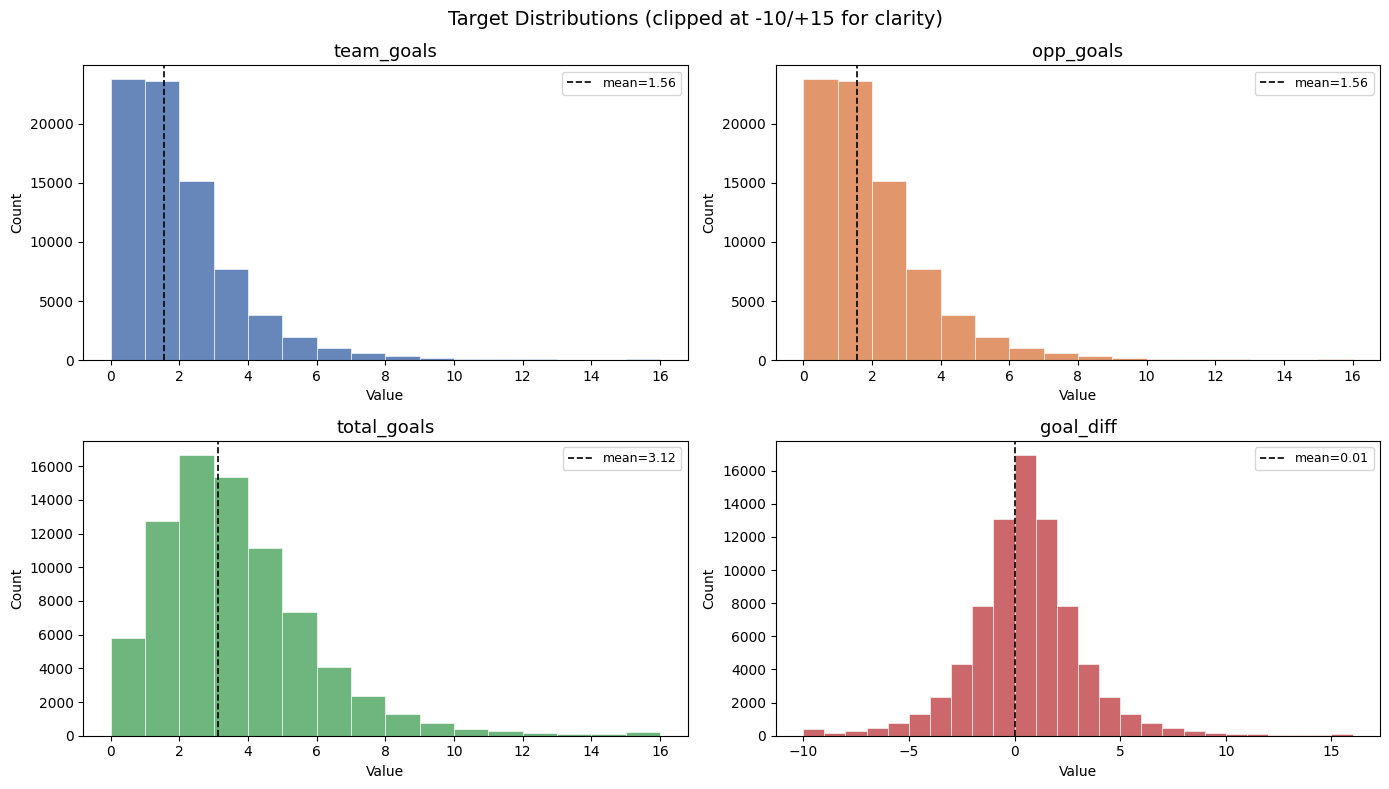

In [3]:
train_raw['total_goals'] = train_raw['team_goals'] + train_raw['opp_goals']
train_raw['goal_diff']   = train_raw['team_goals'] - train_raw['opp_goals']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
for ax, (col, color) in zip(axes, [('team_goals','#4C72B0'),('opp_goals','#DD8452'),
                                     ('total_goals','#55A868'),('goal_diff','#C44E52')]):
    v = train_raw[col].clip(-10, 15)
    ax.hist(v, bins=range(int(v.min()), int(v.max())+2),
            color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(col, fontsize=13)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.axvline(v.mean(), color='black', linestyle='--', lw=1.2,
               label=f'mean={v.mean():.2f}')
    ax.legend(fontsize=9)
fig.suptitle('Target Distributions (clipped at -10/+15 for clarity)', fontsize=14)
plt.tight_layout(); plt.show()

In [4]:
# Outcome breakdown
def get_outcome(gd):
    return 'Win' if gd > 0 else ('Loss' if gd < 0 else 'Draw')

train_raw['outcome'] = train_raw['goal_diff'].apply(get_outcome)
print('Outcome distribution (row-level):')
print(train_raw['outcome'].value_counts().to_string())

print('\nMissing % in shared numeric features (test):')
shared_num = ['population_team','population_opp','gdp_per_capita_team','gdp_per_capita_opp',
              'altitude_venue','distance_travel_team','distance_travel_opp','temperature_venue']
print((test_raw[shared_num].isnull().mean()*100).round(1).to_string())

print('\nTop 10 tournaments in test:')
print(test_raw['tournament'].value_counts().head(10).to_string())

Outcome distribution (row-level):
outcome
Win     30910
Loss    30910
Draw    16952

Missing % in shared numeric features (test):
population_team          7.9
population_opp           7.9
gdp_per_capita_team     34.6
gdp_per_capita_opp      34.6
altitude_venue          25.7
distance_travel_team    40.0
distance_travel_opp     40.0
temperature_venue       13.2

Top 10 tournaments in test:
tournament
Friendly                                10940
FIFA World Cup qualification             8148
UEFA Euro qualification                  3222
African Cup of Nations qualification     2160
UEFA Nations League                      1952
CONCACAF Nations League                   844
African Cup of Nations                    844
AFC Asian Cup qualification               788
FIFA World Cup                            720
UEFA Euro                                 604


## 4. Validation Strategy

**Anti-leakage time-based split with match_id grouping:**
- Matches sorted chronologically; last 20% form the validation set.
- All rows with the same `match_id` remain in the same partition.
- AW-MAE evaluation uses exactly one row per `match_id`.

In [5]:
def make_time_split(df, val_frac=0.20):
    match_dates = df.groupby('match_id')['date'].min().sort_values().reset_index()
    n = len(match_dates)
    cutoff_idx  = int(n * (1 - val_frac))
    cutoff_date = match_dates.iloc[cutoff_idx]['date']
    val_ids = set(match_dates.iloc[cutoff_idx:]['match_id'])
    is_val  = df['match_id'].isin(val_ids)
    print(f'Cutoff date : {cutoff_date.date()}')
    print(f'Train rows  : {(~is_val).sum():>7,}  | unique matches: {df.loc[~is_val,"match_id"].nunique():,}')
    print(f'Val rows    : {is_val.sum():>7,}  | unique matches: {df.loc[is_val,"match_id"].nunique():,}')
    return is_val

## 5. Official AW-MAE Evaluator

In [6]:
def tournament_weight(t: str) -> float:
    """AW-MAE competition weight — keyword-based, case-insensitive, extensible."""
    t = str(t).lower().strip()
    if 'fifa world cup' in t and 'qualif' not in t: return 2.00
    if any(k in t for k in ['afc championship','afc asian cup','asian cup']): return 1.80
    if any(k in t for k in ['friendly match','friendly']): return 0.96
    return 1.20


def aw_mae_match(tg_true, og_true, tg_pred, og_pred, weight=1.0):
    mae    = (abs(tg_true-tg_pred) + abs(og_true-og_pred)) / 2.0
    exact  = int(tg_true==tg_pred and og_true==og_pred)
    sign   = lambda t,o: 1 if t>o else (-1 if t<o else 0)
    outcome= int(sign(tg_true,og_true)==sign(tg_pred,og_pred))
    gd_ok  = int((tg_true-og_true)==(tg_pred-og_pred))
    penalty    = 0.30*(1-exact) + 0.25*(1-outcome) + 0.15*(1-gd_ok)
    multiplier = 1.0 if outcome else 1.5
    loss   = (( mae + penalty ) * multiplier) ** 1.5
    return dict(mae=mae,exact=exact,outcome=outcome,gd=gd_ok,
                penalty=penalty,multiplier=multiplier,loss=loss,weight=weight)


def compute_aw_mae(df_val, tg_pred_col='tg_pred', og_pred_col='og_pred',
                   tg_true_col='team_goals', og_true_col='opp_goals'):
    """Canonical AW-MAE — one score per match_id (deduplicated by first Id)."""
    df_m = df_val.sort_values('Id').drop_duplicates(subset='match_id',keep='first').copy()
    records = []
    for _,row in df_m.iterrows():
        w   = tournament_weight(row['tournament'])
        rec = aw_mae_match(int(row[tg_true_col]),int(row[og_true_col]),
                           int(row[tg_pred_col]),int(row[og_pred_col]),weight=w)
        records.append(rec)
    R = pd.DataFrame(records)
    aw_mae = (R['loss']*R['weight']).sum()/R['weight'].sum()
    return dict(aw_mae=aw_mae, base_mae=R['mae'].mean(),
                exact_rate=R['exact'].mean(), outcome_acc=R['outcome'].mean(),
                gd_acc=R['gd'].mean(), n_matches=len(R))


assert aw_mae_match(2,1,2,1)['loss'] == 0.0
print('AW-MAE evaluator verified.')
print(f'  Perfect pred : {aw_mae_match(2,1,2,1)["loss"]:.4f}')
print(f'  Wrong outcome: {aw_mae_match(2,1,0,2)["loss"]:.4f}')

AW-MAE evaluator verified.
  Perfect pred : 0.0000
  Wrong outcome: 5.9947


## 6. Preprocessing & Label Encoding

In [7]:
CAT_COLS = ['gender','confederation_team','confederation_opp',
            'team','opponent','tournament','venue_country']

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([train_raw[col].astype(str),
                          test_raw[col].astype(str)], ignore_index=True)
    le.fit(combined)
    encoders[col] = le
print('Label encoders fitted on train+test union.')


def preprocess(df, is_train=True):
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'])
    df['altitude_venue'] = df['altitude_venue'].replace(-9999, np.nan)
    for col, le in encoders.items():
        df[col+'_enc'] = le.transform(df[col].astype(str))
    if is_train:
        df['total_goals'] = df['team_goals'] + df['opp_goals']
        df['goal_diff']   = df['team_goals'] - df['opp_goals']
    return df


train = preprocess(train_raw, is_train=True)
test  = preprocess(test_raw,  is_train=False)
print(f'Preprocessing done. train={train.shape}  test={test.shape}')

Label encoders fitted on train+test union.
Preprocessing done. train=(78772, 57)  test=(42422, 27)


## 7. Feature Engineering

All features are derived solely from columns present in **test.csv** (20 base columns).

In [8]:
def add_features(df):
    df = df.copy()
    # Date
    df['year']       = df['date'].dt.year
    df['month']      = df['date'].dt.month
    df['year_frac']  = df['year'] + (df['month']-1)/12
    # Tournament weight as numeric feature
    df['tourn_weight'] = df['tournament'].apply(tournament_weight)
    # Population
    df['log_pop_team'] = np.log1p(df['population_team'])
    df['log_pop_opp']  = np.log1p(df['population_opp'])
    df['log_pop_diff'] = df['log_pop_team'] - df['log_pop_opp']
    # GDP
    df['log_gdp_team'] = np.log1p(df['gdp_per_capita_team'])
    df['log_gdp_opp']  = np.log1p(df['gdp_per_capita_opp'])
    df['log_gdp_diff'] = df['log_gdp_team'] - df['log_gdp_opp']
    df['log_gdp_sum']  = df['log_gdp_team'] + df['log_gdp_opp']
    # Venue
    df['altitude_pos'] = df['altitude_venue'].clip(lower=0)
    df['travel_diff']  = df['distance_travel_team'] - df['distance_travel_opp']
    return df

train = add_features(train)
test  = add_features(test)

FEATURES = [
    'team_enc','opponent_enc','confederation_team_enc','confederation_opp_enc',
    'gender_enc','tournament_enc','venue_country_enc',
    'is_home','neutral','tourn_weight',
    'year','month','year_frac',
    'log_pop_team','log_pop_opp','log_pop_diff',
    'log_gdp_team','log_gdp_opp','log_gdp_diff','log_gdp_sum',
    'altitude_pos','altitude_venue',
    'distance_travel_team','distance_travel_opp','travel_diff',
    'temperature_venue',
]

# Verify all features exist in both
for f in FEATURES:
    assert f in train.columns and f in test.columns, f'Missing: {f}'

print(f'Features: {len(FEATURES)}')
print(FEATURES)

Features: 26
['team_enc', 'opponent_enc', 'confederation_team_enc', 'confederation_opp_enc', 'gender_enc', 'tournament_enc', 'venue_country_enc', 'is_home', 'neutral', 'tourn_weight', 'year', 'month', 'year_frac', 'log_pop_team', 'log_pop_opp', 'log_pop_diff', 'log_gdp_team', 'log_gdp_opp', 'log_gdp_diff', 'log_gdp_sum', 'altitude_pos', 'altitude_venue', 'distance_travel_team', 'distance_travel_opp', 'travel_diff', 'temperature_venue']


## 8. Apply Validation Split

In [9]:
is_val = make_time_split(train, val_frac=0.20)
tr = train[~is_val].copy()
va = train[ is_val].copy()
X_tr, X_va = tr[FEATURES], va[FEATURES]
print(f'X_tr: {X_tr.shape}  |  X_va: {X_va.shape}')

Cutoff date : 2005-02-01
Train rows  :  63,016  | unique matches: 31,508
Val rows    :  15,756  | unique matches: 7,878
X_tr: (63016, 26)  |  X_va: (15756, 26)


## 9. Modeling

In [10]:
LGBM_PARAMS = dict(
    n_estimators=2000, learning_rate=0.03,
    max_depth=7, num_leaves=63, min_child_samples=40,
    subsample=0.80, subsample_freq=1, colsample_bytree=0.70,
    reg_alpha=0.10, reg_lambda=1.50,
    random_state=SEED, n_jobs=-1, verbose=-1,
)
cb_early  = lgb.early_stopping(stopping_rounds=100, verbose=False)
cb_silent = lgb.log_evaluation(period=-1)

# Decomposition models
print('Training model_total ...')
model_total = lgb.LGBMRegressor(**LGBM_PARAMS)
model_total.fit(X_tr, tr['total_goals'],
                eval_set=[(X_va, va['total_goals'])],
                callbacks=[cb_early, cb_silent])
print(f'  best_iter={model_total.best_iteration_}')

print('Training model_gdiff ...')
model_gdiff = lgb.LGBMRegressor(**LGBM_PARAMS)
model_gdiff.fit(X_tr, tr['goal_diff'],
                eval_set=[(X_va, va['goal_diff'])],
                callbacks=[cb_early, cb_silent])
print(f'  best_iter={model_gdiff.best_iteration_}')

Training model_total ...
  best_iter=163
Training model_gdiff ...
  best_iter=825


In [11]:
# Direct-prediction baseline
print('Training direct-prediction baseline ...')
model_direct_tg = lgb.LGBMRegressor(**LGBM_PARAMS)
model_direct_tg.fit(X_tr, tr['team_goals'],
                    eval_set=[(X_va, va['team_goals'])],
                    callbacks=[cb_early, cb_silent])
model_direct_og = lgb.LGBMRegressor(**LGBM_PARAMS)
model_direct_og.fit(X_tr, tr['opp_goals'],
                    eval_set=[(X_va, va['opp_goals'])],
                    callbacks=[cb_early, cb_silent])
print(f'  tg best_iter={model_direct_tg.best_iteration_}  '
      f'og best_iter={model_direct_og.best_iteration_}')

Training direct-prediction baseline ...
  tg best_iter=573  og best_iter=617


## 10. Post-Processing Helpers

In [12]:
def reconstruct_goals(pred_total, pred_gdiff, shrink=0.0, min_g=0):
    """
    Reconstruct integer team/opp goals from continuous total+diff predictions.
    shrink: shrinkage of goal_diff toward 0 (tunes toward draws)
    """
    pt  = np.asarray(pred_total, dtype=float)
    pgd = np.asarray(pred_gdiff, dtype=float) * (1 - shrink)
    raw_tg = (pt + pgd) / 2.0
    raw_og = (pt - pgd) / 2.0
    tg = np.clip(np.round(raw_tg).astype(int), min_g, None)
    og = np.clip(np.round(raw_og).astype(int), min_g, None)
    return tg, og


def postprocess_direct(pred_tg, pred_og, min_g=0):
    tg = np.clip(np.round(np.asarray(pred_tg)).astype(int), min_g, None)
    og = np.clip(np.round(np.asarray(pred_og)).astype(int), min_g, None)
    return tg, og


print('Post-processing helpers defined.')

Post-processing helpers defined.


## 11. Evaluation on Validation Set

In [13]:
va_pred_total   = model_total.predict(X_va)
va_pred_gdiff   = model_gdiff.predict(X_va)
va_pred_tg_dir  = model_direct_tg.predict(X_va)
va_pred_og_dir  = model_direct_og.predict(X_va)

# Tune shrink_draw on AW-MAE
print('Tuning shrink_draw ...')
shrink_results = []
for shrink in np.arange(0.0, 0.41, 0.05):
    tg, og = reconstruct_goals(va_pred_total, va_pred_gdiff, shrink=shrink)
    ev = va.copy()
    ev['tg_pred'] = tg; ev['og_pred'] = og
    m = compute_aw_mae(ev, 'tg_pred', 'og_pred')
    shrink_results.append({'shrink': shrink, **m})
    print(f'  shrink={shrink:.2f}  AW-MAE={m["aw_mae"]:.5f}  '
          f'Exact={m["exact_rate"]:.3f}  Outcome={m["outcome_acc"]:.3f}  GD={m["gd_acc"]:.3f}')

best_shrink = min(shrink_results, key=lambda r: r['aw_mae'])['shrink']
print(f'\nBest shrink={best_shrink:.2f}')

Tuning shrink_draw ...
  shrink=0.00  AW-MAE=3.28737  Exact=0.089  Outcome=0.543  GD=0.227
  shrink=0.05  AW-MAE=3.27732  Exact=0.089  Outcome=0.541  GD=0.228
  shrink=0.10  AW-MAE=3.27032  Exact=0.090  Outcome=0.540  GD=0.232
  shrink=0.15  AW-MAE=3.28451  Exact=0.090  Outcome=0.536  GD=0.232
  shrink=0.20  AW-MAE=3.29568  Exact=0.089  Outcome=0.531  GD=0.235
  shrink=0.25  AW-MAE=3.30244  Exact=0.089  Outcome=0.528  GD=0.236
  shrink=0.30  AW-MAE=3.31743  Exact=0.089  Outcome=0.523  GD=0.237
  shrink=0.35  AW-MAE=3.33727  Exact=0.088  Outcome=0.517  GD=0.238
  shrink=0.40  AW-MAE=3.37188  Exact=0.087  Outcome=0.507  GD=0.236

Best shrink=0.10


In [14]:
# Final validation metrics
va_tg_d, va_og_d = reconstruct_goals(va_pred_total, va_pred_gdiff, shrink=best_shrink)
va_eval_decomp = va.copy()
va_eval_decomp['tg_pred'] = va_tg_d; va_eval_decomp['og_pred'] = va_og_d
metrics_decomp = compute_aw_mae(va_eval_decomp, 'tg_pred', 'og_pred')

va_tg_b, va_og_b = postprocess_direct(va_pred_tg_dir, va_pred_og_dir)
va_eval_direct = va.copy()
va_eval_direct['tg_pred'] = va_tg_b; va_eval_direct['og_pred'] = va_og_b
metrics_direct = compute_aw_mae(va_eval_direct, 'tg_pred', 'og_pred')

comparison = pd.DataFrame([
    {'Approach': 'Decomposition (total+gdiff)', **metrics_decomp},
    {'Approach': 'Direct prediction (baseline)', **metrics_direct},
]).set_index('Approach')

print('\n===== Validation Results =====')
print(comparison.to_string(float_format=lambda x: f'{x:.5f}'))

USE_DECOMP    = metrics_decomp['aw_mae'] <= metrics_direct['aw_mae']
best_approach = 'Decomposition' if USE_DECOMP else 'Direct'
print(f'\n-> Selected for final inference: {best_approach}')


===== Validation Results =====
                              aw_mae  base_mae  exact_rate  outcome_acc  gd_acc  n_matches
Approach                                                                                  
Decomposition (total+gdiff)  3.27032   1.06518     0.09000      0.54037 0.23166       7878
Direct prediction (baseline) 3.34117   1.07692     0.08657      0.52920 0.22899       7878

-> Selected for final inference: Decomposition


In [15]:
# Sample predictions vs actuals
sample = va.copy()
sample['tg_pred'] = va_tg_d; sample['og_pred'] = va_og_d
show = ['date','team','opponent','tournament','team_goals','opp_goals',
        'total_goals','goal_diff','tg_pred','og_pred']
smpl = (sample.sort_values('Id').drop_duplicates('match_id',keep='first')[show]
              .sample(20, random_state=SEED).sort_values('date'))
smpl['pred_gd'] = smpl['tg_pred'] - smpl['og_pred']
print('Sample reconstruction vs actuals (decomposition):')
print(smpl.to_string(index=False))

Sample reconstruction vs actuals (decomposition):
      date                   team        opponent                         tournament  team_goals  opp_goals  total_goals  goal_diff  tg_pred  og_pred  pred_gd
2005-06-01                  Gabon          Zambia                           Friendly           0          1            1         -1        1        1        0
2005-11-27               Djibouti         Somalia                         CECAFA Cup           1          2            3         -1        1        2       -1
2006-08-12              Hong Kong       Singapore                           Friendly           1          2            3         -1        1        1        0
2006-10-07                England North Macedonia            UEFA Euro qualification           0          0            0          0        2        0        2
2007-01-14            Philippines        Thailand                   AFF Championship           0          4            4         -4        1        3      

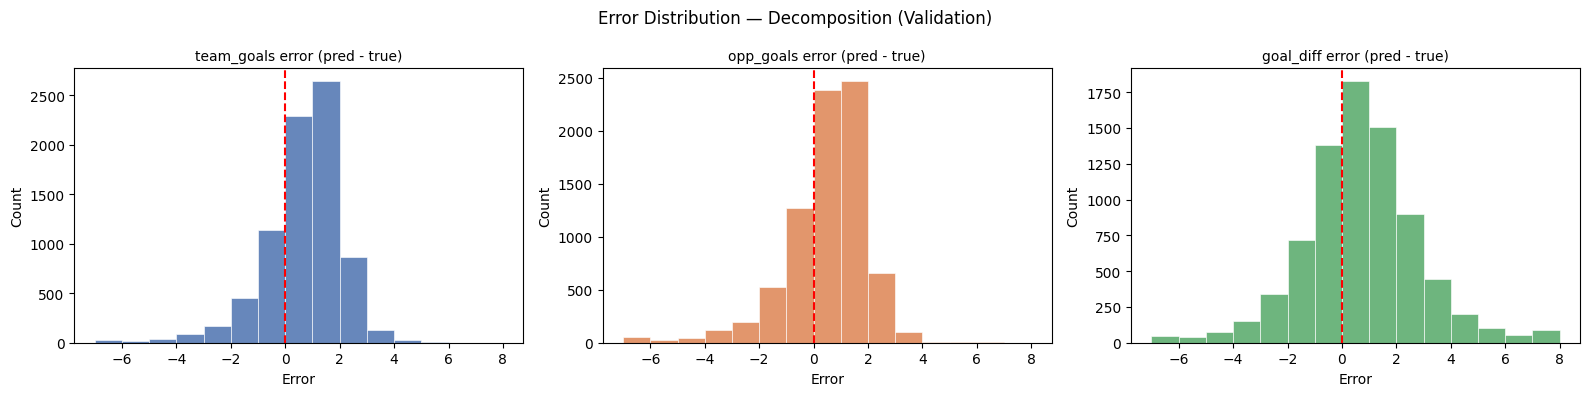

In [16]:
# Error distribution
m_eval = va_eval_decomp.sort_values('Id').drop_duplicates('match_id').copy()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (err, title, color) in zip(axes, [
    (m_eval['tg_pred']-m_eval['team_goals'], 'team_goals error','#4C72B0'),
    (m_eval['og_pred']-m_eval['opp_goals'],  'opp_goals error', '#DD8452'),
    ((m_eval['tg_pred']-m_eval['og_pred'])-(m_eval['team_goals']-m_eval['opp_goals']),
     'goal_diff error','#55A868')
]):
    ax.hist(err.clip(-7,7), bins=range(-7,9), color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(f'{title} (pred - true)', fontsize=10)
    ax.set_xlabel('Error'); ax.set_ylabel('Count')
    ax.axvline(0, color='red', linestyle='--')
fig.suptitle('Error Distribution — Decomposition (Validation)', fontsize=12)
plt.tight_layout(); plt.show()

## 12. Feature Importance

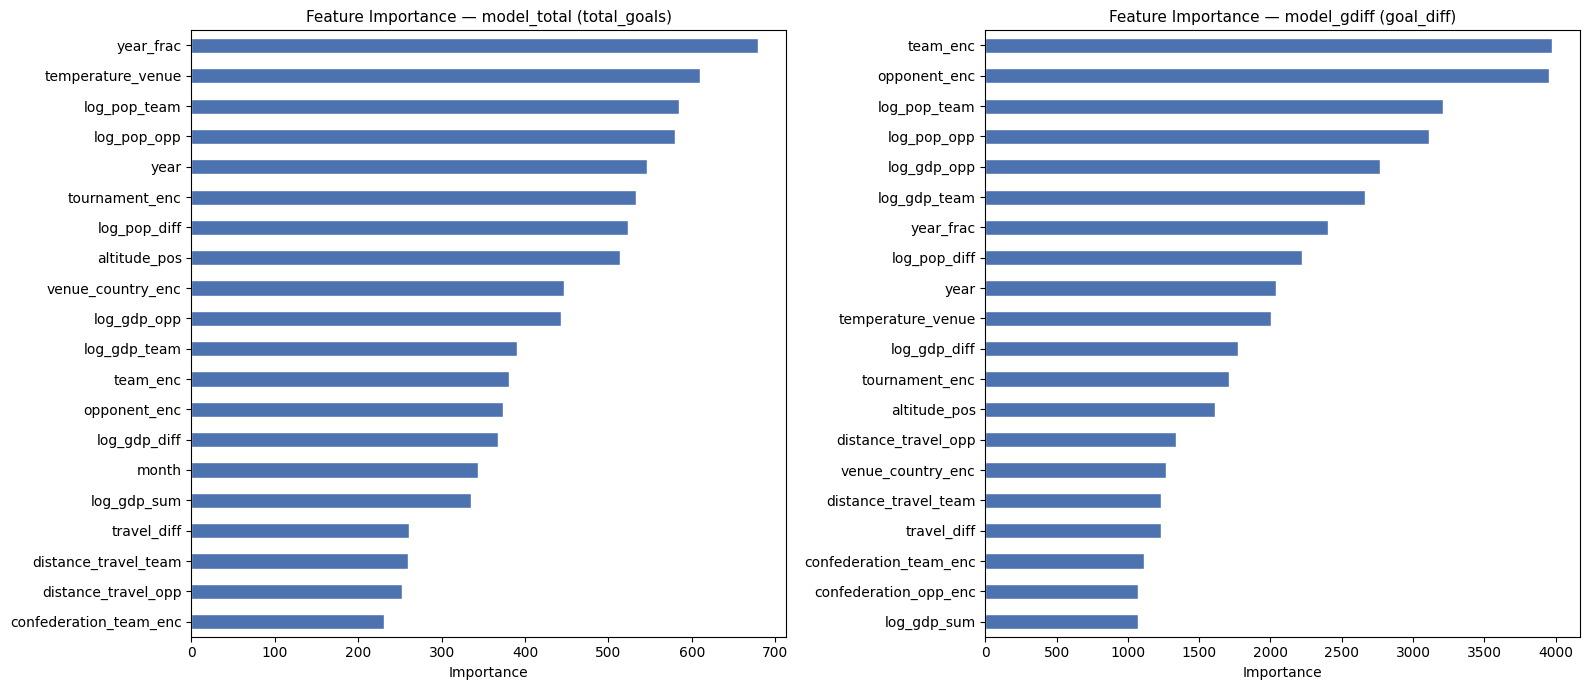

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, m, t in zip(axes, [model_total, model_gdiff],
                    ['model_total (total_goals)', 'model_gdiff (goal_diff)']):
    imp = pd.Series(m.feature_importances_, index=FEATURES).nlargest(20)
    imp.sort_values().plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Feature Importance — {t}', fontsize=11)
    ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

## 13. Retrain on Full Training Data

In [18]:
X_all = train[FEATURES]
n_est = max(model_total.best_iteration_, model_gdiff.best_iteration_) + 50
print(f'Final n_estimators: {n_est}')

LGBM_FINAL = {**{k:v for k,v in LGBM_PARAMS.items() if k!='n_estimators'}, 'n_estimators': n_est}

print('Retraining model_total on full data ...')
final_total = lgb.LGBMRegressor(**LGBM_FINAL)
final_total.fit(X_all, train['total_goals'])

print('Retraining model_gdiff on full data ...')
final_gdiff = lgb.LGBMRegressor(**LGBM_FINAL)
final_gdiff.fit(X_all, train['goal_diff'])

if not USE_DECOMP:
    n_est_d = max(model_direct_tg.best_iteration_, model_direct_og.best_iteration_) + 50
    LGBM_FINAL_D = {**{k:v for k,v in LGBM_PARAMS.items() if k!='n_estimators'}, 'n_estimators': n_est_d}
    final_dir_tg = lgb.LGBMRegressor(**LGBM_FINAL_D)
    final_dir_tg.fit(X_all, train['team_goals'])
    final_dir_og = lgb.LGBMRegressor(**LGBM_FINAL_D)
    final_dir_og.fit(X_all, train['opp_goals'])

print('Full-data retraining complete.')

Final n_estimators: 875
Retraining model_total on full data ...
Retraining model_gdiff on full data ...
Full-data retraining complete.


## 14. Final Inference on test.csv

In [19]:
X_test = test[FEATURES]

if USE_DECOMP:
    t_pred = final_total.predict(X_test)
    g_pred = final_gdiff.predict(X_test)
    test_tg, test_og = reconstruct_goals(t_pred, g_pred, shrink=best_shrink)
else:
    test_tg, test_og = postprocess_direct(final_dir_tg.predict(X_test),
                                           final_dir_og.predict(X_test))

print(f'Inference done ({best_approach}).')
print(f'team_goals: min={test_tg.min()} max={test_tg.max()} mean={test_tg.mean():.3f}')
print(f'opp_goals : min={test_og.min()} max={test_og.max()} mean={test_og.mean():.3f}')

Inference done (Decomposition).
team_goals: min=0 max=11 mean=1.565
opp_goals : min=0 max=12 mean=1.557


## 15. Build and Save Submission CSV

In [20]:
submission = pd.DataFrame({
    'Id'        : test['Id'],
    'team_goals': test_tg.astype(int),
    'opp_goals' : test_og.astype(int),
})

assert len(submission) == len(test)
assert list(submission.columns) == ['Id','team_goals','opp_goals']
assert (submission['team_goals'] >= 0).all()
assert (submission['opp_goals']  >= 0).all()

out_path = os.path.join(OUTPUT_DIR, OUTPUT_CSV)
submission.to_csv(out_path, index=False)
print(f'\nSubmission saved: {out_path}')
print(f'Shape: {submission.shape}')
submission.head(10)


Submission saved: ../Submission/exp04_total_goals_goal_diff.csv\exp04_total_goals_goal_diff.csv
Shape: (42422, 3)


,Id,team_goals,opp_goals
0,M034984_Seychelles,1,1
1,M034984_Mauritius,1,1
2,M034985_Comoros,1,1
3,M034985_Maldives,2,2
4,M034986_Réunion,1,1
5,M034986_Madagascar,1,1
6,M034987_El Salvador,1,2
7,M034987_Venezuela,2,1
8,M034988_Mayotte,2,2
9,M034988_Réunion,2,2


## 16. Error Analysis

In [21]:
# Per-tournament breakdown
def per_tourn_breakdown(ev_df):
    df_m = ev_df.sort_values('Id').drop_duplicates('match_id', keep='first').copy()
    rows = []
    for _, row in df_m.iterrows():
        w   = tournament_weight(row['tournament'])
        rec = aw_mae_match(int(row['team_goals']), int(row['opp_goals']),
                           int(row['tg_pred']),    int(row['og_pred']), weight=w)
        rec['tournament'] = row['tournament']
        rows.append(rec)
    df_r = pd.DataFrame(rows)
    return (df_r.groupby('tournament')
                .agg(n=('loss','count'), aw_mae=('loss','mean'),
                     exact_rate=('exact','mean'), outcome_acc=('outcome','mean'),
                     gd_acc=('gd','mean'), base_mae=('mae','mean'))
                .sort_values('aw_mae', ascending=False))

print('Per-tournament breakdown (top 20):')
print(per_tourn_breakdown(va_eval_decomp).head(20).to_string(float_format=lambda x: f'{x:.4f}'))

Per-tournament breakdown (top 20):
                                                        n  aw_mae  exact_rate  outcome_acc  gd_acc  base_mae
tournament                                                                                                  
SAFF Championship                                      15  8.1244      0.0000       0.7333  0.1333    2.6333
South Asian Games                                      10  7.7339      0.0000       0.6000  0.1000    2.2000
Arab Championship                                      13  7.4783      0.0000       0.5385  0.0769    2.3077
Pacific Games                                          20  6.8792      0.0000       0.4500  0.0000    1.9000
Viva World Cup                                         42  6.6465      0.0000       0.3810  0.0714    1.9167
WAFF Championship                                      55  6.6392      0.0727       0.5455  0.1818    1.8000
OFC Championship                                       22  6.4060      0.0455       0.7273  0

In [22]:
# Worst matches
rows = []
df_m = va_eval_decomp.sort_values('Id').drop_duplicates('match_id').copy()
for _, row in df_m.iterrows():
    w   = tournament_weight(row['tournament'])
    rec = aw_mae_match(int(row['team_goals']), int(row['opp_goals']),
                       int(row['tg_pred']),    int(row['og_pred']), weight=w)
    rec.update({'date': str(row['date'])[:10], 'team': row['team'],
                'opponent': row['opponent'], 'tournament': row['tournament'],
                'actual': f"{int(row['team_goals'])}-{int(row['opp_goals'])}",
                'pred':   f"{int(row['tg_pred'])}-{int(row['og_pred'])}"})
    rows.append(rec)

worst = pd.DataFrame(rows).sort_values('loss', ascending=False)
print('Worst 15 matches (highest loss):')
print(worst[['date','team','opponent','tournament','actual','pred','loss']]
      .head(15).to_string(index=False))

Worst 15 matches (highest loss):
      date                   team            opponent                                           tournament actual pred      loss
2006-11-10               Cameroon        South Africa                                 African Championship   2-24  2-2 73.521724
2010-02-22                 Kuwait           Palestine                                    WAFF Championship   0-17  4-1 64.300234
2005-05-03               Chechnya           Occitania                                             Friendly   0-14  2-1 43.137768
2010-08-21             Azerbaijan               Wales                         FIFA World Cup qualification   0-15  2-2 43.137768
2007-10-05                   Cuba U.S. Virgin Islands CONCACAF Olympic Qualifying Tournament qualification   14-0  2-2 39.253011
2009-12-04               Malaysia            Thailand                                Southeast Asian Games   0-14  2-2 39.253011
2010-12-18                  Nepal            Pakistan           

## 17. Conclusion

### Summary

| Component | Detail |
|---|---|
| **Data representation** | Row-wise (2 rows per match); match-level deduplication only for AW-MAE scoring |
| **Target decomposition** | `total_goals = team_goals + opp_goals`, `goal_diff = team_goals - opp_goals` |
| **Reconstruction** | `tg = round((total + diff*(1-shrink))/2)`, `og = round((total - diff*(1-shrink))/2)` |
| **Models** | Two LightGBM regressors: model_total, model_gdiff |
| **Validation** | Time-based split, last 20% of matches, match_id grouped (no leakage) |
| **Post-processing** | `shrink_draw` grid-tuned on AW-MAE; round; clip min=0; int cast |
| **Model selection** | Best of Decomposition vs Direct by AW-MAE validation |
| **Output** | `exp04_total_goals_goal_diff.csv` — `Id`, `team_goals`, `opp_goals` |

### Features used (all derivable from test.csv)
Team/opponent identity (label-encoded), confederation, tournament, venue country, gender,
home/neutral, tournament AW-MAE weight, year/month/time trend,
log-population (team, opp, diff), log-GDP (team, opp, diff, sum),
altitude, travel distances (team, opp, diff), temperature.

### Why decomposition aligns with AW-MAE
The AW-MAE formula penalises three components: Exact Score, Outcome, and Goal Difference.
By modelling `goal_diff` directly, we optimise the representation for Outcome and GD signals.
By modelling `total_goals` separately, we give the model a dedicated channel for scoring intensity.
The optional `shrink_draw` post-processing reduces overconfident margins to further improve Outcome accuracy.